<a href="https://colab.research.google.com/github/QangDuc/deeplearning/blob/main/TH_DLN_Tuan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Autoencoder

In [2]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 920.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 152.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 98.2 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


--- 1. Đang huấn luyện Autoencoder giữ form ảnh nguyên bản ---
Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 80ms/step - loss: 0.3177 - val_loss: 0.4354
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 0.1689 - val_loss: 0.3338
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - loss: 0.1364 - val_loss: 0.1990
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - loss: 0.1150 - val_loss: 0.1384
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 0.1094 - val_loss: 0.1356
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 0.1046 - val_loss: 0.1458
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 0.0913 - val_loss: 0.1233
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 0.0895 - val_loss: 0.1151
Epoch 9/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 0.0836 - val_loss: 0.1039
Epoch 10/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 0.0819 - val_loss: 0.1070
Epoch 11/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step -

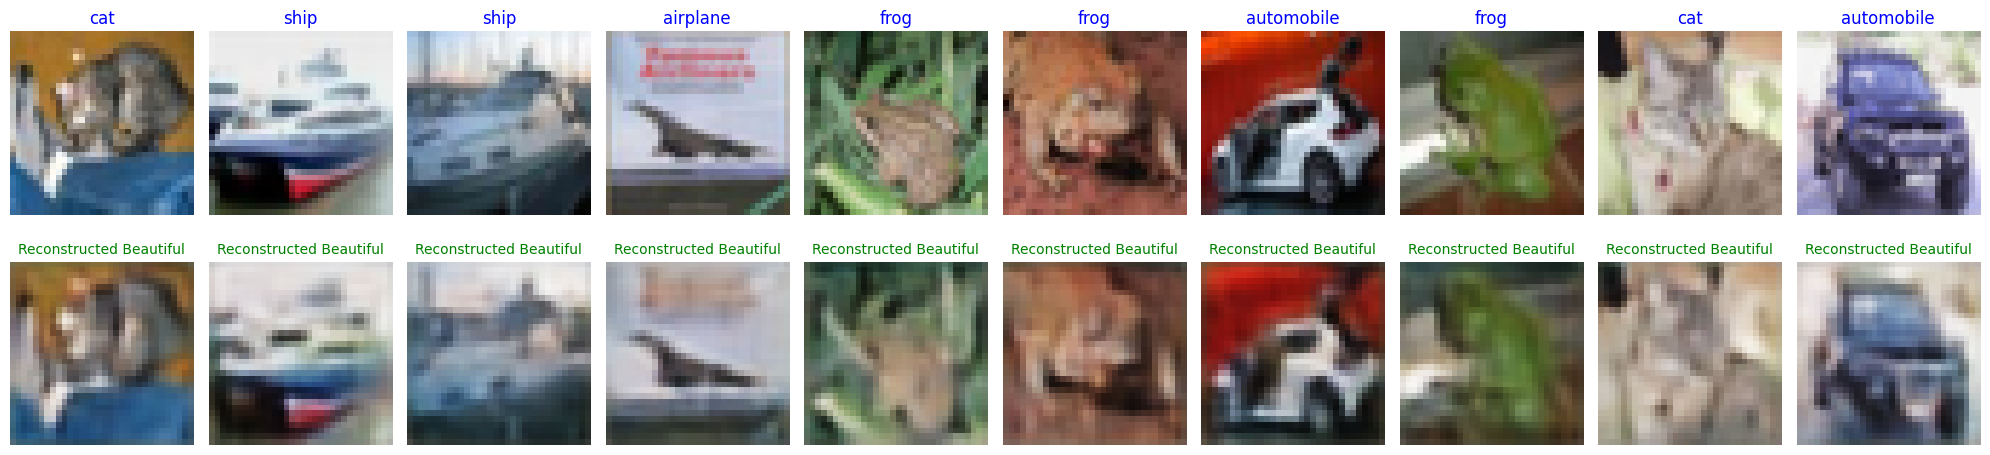

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

# 1. Tải và tiền xử lý dữ liệu CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

cifar10_labels = {
    0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer',
    5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'
}

# 2. Hàm Loss kết hợp giúp ảnh sắc nét
def custom_ssim_mse_loss(y_true, y_pred):
    mse_loss = tf.reduce_mean(tf.square(y_true - y_pred))
    ssim_loss = tf.reduce_mean(1.0 - tf.image.ssim(y_true, y_pred, max_val=1.0))
    return mse_loss + 0.4 * ssim_loss

input_img = layers.Input(shape=(32, 32, 3))

# --- Encoder ---
x = layers.Conv2D(64, (3, 3), padding='same', name='enc_conv1')(input_img)
x = layers.BatchNormalization(name='enc_bn1')(x)
x = layers.Activation('relu', name='enc_act1')(x)

x = layers.Conv2D(64, (3, 3), padding='same', name='enc_conv2')(x)
x = layers.BatchNormalization(name='enc_bn2')(x)
x = layers.Activation('relu', name='enc_act2')(x)
x = layers.MaxPooling2D((2, 2), padding='same', name='enc_pool1')(x)

x = layers.Conv2D(32, (3, 3), padding='same', activity_regularizer=regularizers.l1(1e-6), name='enc_conv3')(x)
x = layers.BatchNormalization(name='enc_bn3')(x)
x = layers.Activation('relu', name='enc_act3')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same', name='latent_space')(x) # Nơi lưu đặc trưng gốc

# --- Decoder ---
x = layers.Conv2D(32, (3, 3), padding='same', name='dec_conv1')(encoded)
x = layers.BatchNormalization(name='dec_bn1')(x)
x = layers.Activation('relu', name='dec_act1')(x)
x = layers.UpSampling2D((2, 2), name='dec_up1')(x)

x = layers.Conv2D(64, (3, 3), padding='same', name='dec_conv2')(x)
x = layers.BatchNormalization(name='dec_bn2')(x)
x = layers.Activation('relu', name='dec_act2')(x)

x = layers.Conv2D(64, (3, 3), padding='same', name='dec_conv3')(x)
x = layers.BatchNormalization(name='dec_bn3')(x)
x = layers.Activation('relu', name='dec_act3')(x)
x = layers.UpSampling2D((2, 2), name='dec_up2')(x)

decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same', name='output_reconstruction')(x)

autoencoder_ssim = models.Model(input_img, decoded)
autoencoder_ssim.compile(optimizer='adam', loss=custom_ssim_mse_loss)

print("--- 1. Đang huấn luyện Autoencoder giữ form ảnh nguyên bản ---")
early_stop_ae = callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
autoencoder_ssim.fit(x_train, x_train, epochs=20, batch_size=256, validation_data=(x_test, x_test), callbacks=[early_stop_ae])


# Việc này đảm bảo trọng số tái tạo ảnh không bao giờ bị lệch màu nữa!
for layer in autoencoder_ssim.layers:
    layer.trainable = False

# Lấy chính xác đầu ra của không gian nén ẩn
latent_output = autoencoder_ssim.get_layer('latent_space').output

# Xây dựng mạng phân loại độc lập ở phía sau
flatten = layers.Flatten()(latent_output)
dense_1 = layers.Dense(512, activation='relu')(flatten) # Mở rộng hẳn lên 512 node để phân loại mạnh hơn
bn_c1 = layers.BatchNormalization()(dense_1)
dropout_1 = layers.Dropout(0.4)(bn_c1)

dense_2 = layers.Dense(256, activation='relu')(dropout_1)
bn_c2 = layers.BatchNormalization()(dense_2)
dropout_2 = layers.Dropout(0.3)(bn_c2)

output_classifier = layers.Dense(10, activation='softmax')(dropout_2)

# Khởi tạo mô hình phân loại riêng biệt
classifier_model = models.Model(inputs=autoencoder_ssim.input, outputs=output_classifier)
classifier_model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

print("\n--- 2. Huấn luyện bộ phân loại tách biệt (Giữ màu ảnh ổn định) ---")
early_stop_clf = callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)
classifier_model.fit(x_train, y_train_cat, epochs=20, batch_size=128, validation_data=(x_test, y_test_cat), callbacks=[early_stop_clf])

decoded_imgs = autoencoder_ssim.predict(x_test)

n = 10
plt.figure(figsize=(20, 5))
for i in range(n):
    # Ảnh gốc
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i])
    plt.title(cifar10_labels[y_test[i][0]], fontsize=12, color='blue')
    plt.axis("off")

    # Ảnh tái tạo chuẩn màu sắc, sắc nét nhờ cấu trúc đóng băng bảo vệ
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstructed Beautiful", fontsize=10, color='green')
    plt.axis("off")
plt.tight_layout()
plt.show()

#RNN

Đang nạp dữ liệu California Housing...
Epoch 1/80


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - loss: 0.0262 - val_loss: 0.0830
Epoch 2/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0166 - val_loss: 0.0270
Epoch 3/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0125 - val_loss: 0.0241
Epoch 4/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0124 - val_loss: 0.0213
Epoch 5/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0124 - val_loss: 0.0315
Epoch 6/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0125 - val_loss: 0.0258
Epoch 7/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0127 - val_loss: 0.0312
Epoch 8/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0118 - val_loss: 0.0257
Epoch 9/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0110 - val_loss: 0.0188
Epoch 10/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0123 - val_loss: 0.0234
Epoch 11/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0105 - val_loss: 0.0182
Epoch 12/80
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0106 - val_l

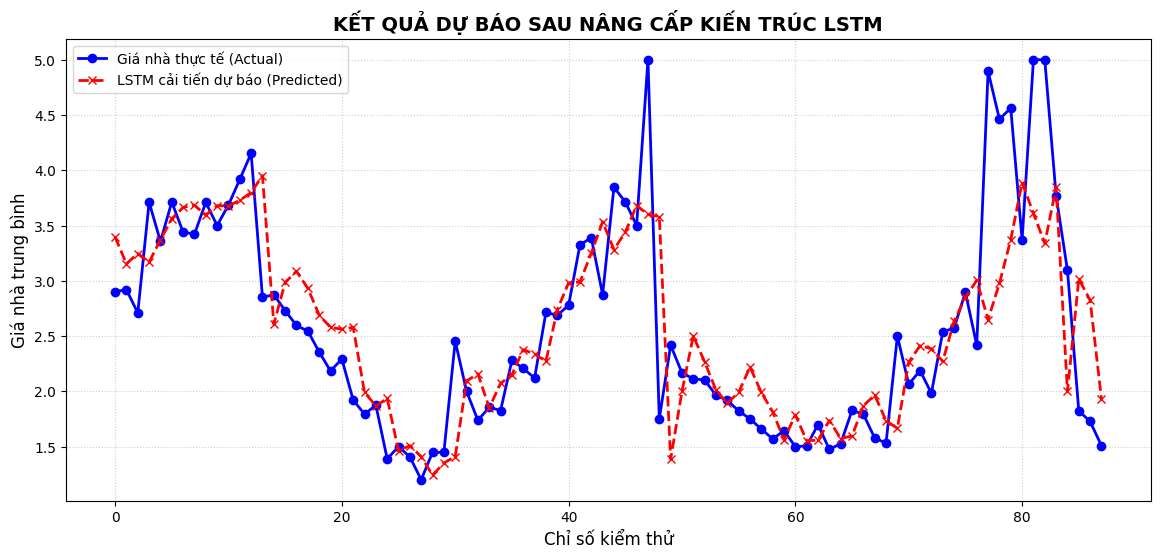

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import fetch_california_housing
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam


print("Đang nạp dữ liệu California Housing...")
housing_data = fetch_california_housing(as_frame=True)
df = housing_data.frame

# Thay vì sắp xếp theo thu nhập gây nhiễu, ta lấy trực tiếp chuỗi phân vùng địa lý liền kề nhau
df = df.rename(columns={'MedHouseVal': 'price'})
data_series = df['price'].iloc[:500].to_frame() # Tăng lượng mẫu lên 500 để LSTM có đủ dữ liệu học đỉnh


#  CHUẨN HÓA VÀ CẮT CHUỖI TIMESTEPS

train_size = int(len(data_series) * 0.80) # 80% Train, 20% Test
train_data = data_series.iloc[:train_size]
test_data = data_series.iloc[train_size:]

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# Tăng look_back lên 12 (nhìn xa hơn về trước) giúp bắt xu hướng tốt hơn
def create_dataset(dataset, look_back=12):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

look_back = 12
X_train, y_train = create_dataset(train_scaled, look_back)
X_test, y_test = create_dataset(test_scaled, look_back)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))


model = Sequential([
    # Sử dụng LSTM thay thế hoàn toàn cho SimpleRNN
    LSTM(units=128, return_sequences=True, input_shape=(look_back, 1)),
    Dropout(0.1), # Giảm dropout xuống một chút để mạng không bỏ sót chi tiết mạnh
    LSTM(units=64, return_sequences=False),
    Dropout(0.1),
    Dense(units=32, activation='relu'), # Thêm tầng trung gian bứt phá tuyến tính
    Dense(units=1)
])

# Tăng tốc độ học tự do (learning_rate) để mô hình dám nhảy vọt theo đỉnh
model.compile(optimizer=Adam(learning_rate=0.005), loss='mean_squared_error')

history = model.fit(
    X_train, y_train,
    epochs=80, # Tăng số epoch huấn luyện lên 80 để hội tụ sâu hơn
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)


predictions_scaled = model.predict(X_test)
predictions = scaler.inverse_transform(predictions_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(14, 6))
indices = np.arange(len(y_test_real))

plt.plot(indices, y_test_real, label='Giá nhà thực tế (Actual)', color='blue', marker='o', linewidth=2)
plt.plot(indices, predictions, label='LSTM cải tiến dự báo (Predicted)', color='red', linestyle='--', marker='x', linewidth=2)

plt.title('KẾT QUẢ DỰ BÁO SAU NÂNG CẤP KIẾN TRÚC LSTM', fontsize=14, fontweight='bold')
plt.xlabel('Chỉ số kiểm thử', fontsize=12)
plt.ylabel('Giá nhà trung bình', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()